# Task 1:Import libraries and setup

In [1]:
# Cell 1: Import libraries and setup
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.append(os.path.abspath('../'))

# Import our OOP classes
from src.data_processor import InsuranceDataProcessor
from src.visualizer import InsuranceVisualizer

# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(" Libraries imported successfully!")

 Libraries imported successfully!


# Initialize and load data

In [2]:
# Cell 2: Initialize and load data
# Initialize data processor
print("📂 LOADING INSURANCE DATA")
print("=" * 50)

# Initialize the data processor
file_path = '../data/MachineLearningRating_v3.txt'
processor = InsuranceDataProcessor(file_path)

# Load the data with pipe delimiter
df = processor.load_data(delimiter='|')

if df is not None:
    print(f" Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
    print(f"\n📋 Column names: {df.columns.tolist()}")
    print(f"\n📊 Data types:")
    print(df.dtypes)
else:
    print(" Failed to load data")
print(f" Dataset Shape: {df.shape}")

print("\n Column Information:")
print(df.info())

📂 LOADING INSURANCE DATA
First line (header): UnderwrittenCoverID|PolicyID|TransactionMonth|IsVATRegistered|Citizenship|LegalType|Title|Language|B...
Second line (data): 145249|12827|2015-03-01 00:00:00|True|  |Close Corporation|Mr|English|First National Bank|Current ac...
Pipes in first line: 51
Pipes in second line: 51
First line appears to be data, using manual column names
Data loaded successfully. Shape: (1000099, 52)
Columns: ['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'Mmcode', 'VehicleType', 'RegistrationYear', 'Make', 'Model', 'Cylinders', 'Cubiccapacity', 'Kilowatts', 'Bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'N

In [8]:
# Add this cell at the beginning of your notebook, after imports

# Cell for initializing visualizer
print("🎨 INITIALIZING VISUALIZATION ENGINE")
print("=" * 50)

# Initialize visualizer
visualizer = InsuranceVisualizer(style='seaborn')
print(" Visualizer initialized successfully!")

🎨 INITIALIZING VISUALIZATION ENGINE
 Visualizer initialized successfully!


# CONVERTING DATA TYPES

In [5]:
print("🔄 CONVERTING DATA TYPES")
print("=" * 50)

# Convert columns to proper data types
processor.convert_data_types()

# Re-analyze structure
structure_info = processor.analyze_data_structure()

print(f"\n📊 UPDATED DATA STRUCTURE:")
print(f"   • Total Rows: {structure_info['total_rows']:,}")
print(f"   • Total Columns: {structure_info['total_columns']}")
print(f"   • Numerical Columns: {len(structure_info['numerical_columns'])}")
print(f"   • Categorical Columns: {len(structure_info['categorical_columns'])}")

if structure_info['potential_numeric_cols']:
    print(f"\n⚠️  Potential numeric columns (currently object type):")
    for col in structure_info['potential_numeric_cols'][:5]:
        print(f"   • {col}")

🔄 CONVERTING DATA TYPES
Converting data types...
Converted RegistrationYear to numeric
Converted Cylinders to numeric
Converted Cubiccapacity to numeric
Converted Kilowatts to numeric
Converted NumberOfDoors to numeric
Converted CustomValueEstimate to numeric
Converted NumberOfVehiclesInFleet to numeric
Converted SumInsured to numeric
Converted CalculatedPremiumPerTerm to numeric
Converted TotalPremium to numeric
Converted TotalClaims to numeric
Converted TransactionMonth to datetime
Converted VehicleIntroDate to datetime

📊 UPDATED DATA STRUCTURE:
   • Total Rows: 1,000,099
   • Total Columns: 52
   • Numerical Columns: 11
   • Categorical Columns: 39

⚠️  Potential numeric columns (currently object type):
   • AccountType
   • Country


# Check First Few Rows

In [9]:
print("👀 FIRST FEW ROWS OF DATA")
print("=" * 50)

if processor.df is not None:
    display(processor.df.head())
    
    print(f"\n📊 SAMPLE OF NUMERICAL COLUMNS:")
    if processor.numerical_cols:
        for col in processor.numerical_cols[:5]:
            print(f"   • {col}: {processor.df[col].dtype}")
            print(f"     Sample values: {processor.df[col].head(3).tolist()}")
    else:
        print("   No numerical columns found yet")

👀 FIRST FEW ROWS OF DATA


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,UnderwrittenCoverID,PolicyID,NaT,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,NaN,NaN
1,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
3,145249,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
4,145255,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0



📊 SAMPLE OF NUMERICAL COLUMNS:
   • RegistrationYear: float64
     Sample values: [nan, 2004.0, 2004.0]
   • Cylinders: float64
     Sample values: [nan, 6.0, 6.0]
   • Cubiccapacity: float64
     Sample values: [nan, 2597.0, 2597.0]
   • Kilowatts: float64
     Sample values: [nan, 130.0, 130.0]
   • NumberOfDoors: float64
     Sample values: [nan, 4.0, 4.0]


# Analyze data structure

In [10]:
# Cell 3: Analyze data structure
structure_info = processor.analyze_data_structure()

print("📐 DATA STRUCTURE ANALYSIS")
print("=" * 50)
print(f"Total Rows: {structure_info['total_rows']:,}")
print(f"Total Columns: {structure_info['total_columns']}")
print(f"Numerical Columns: {len(structure_info['numerical_columns'])}")
print(f"Categorical Columns: {len(structure_info['categorical_columns'])}")
print(f"Potential Date Columns: {structure_info['date_pattern_columns']}")
print("\n" + "=" * 50)

📐 DATA STRUCTURE ANALYSIS
Total Rows: 1,000,099
Total Columns: 52
Numerical Columns: 11
Categorical Columns: 39
Potential Date Columns: ['TransactionMonth', 'RegistrationYear', 'VehicleIntroDate']



# Display sample data

In [11]:
# Cell 4: Display sample data
print("📄 SAMPLE DATA (First 5 rows)")
print("=" * 60)
display(df.head())
print("\n" + "=" * 60)

print("\n📄 COLUMN DATA TYPES")
print("=" * 60)
display(pd.DataFrame(df.dtypes, columns=['Data Type']).head(20))

📄 SAMPLE DATA (First 5 rows)


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,UnderwrittenCoverID,PolicyID,NaT,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,NaN,NaN
1,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
3,145249,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
4,145255,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0




📄 COLUMN DATA TYPES


,Data Type
UnderwrittenCoverID,object
PolicyID,object
TransactionMonth,datetime64[ns]
IsVATRegistered,object
Citizenship,object
LegalType,object
Title,object
Language,object
Bank,object
AccountType,object


# Calculate descriptive statistics

In [7]:
# Cell 5: Calculate descriptive statistics
print("📈 DESCRIPTIVE STATISTICS FOR KEY NUMERICAL FEATURES")
print("=" * 80)

# Get stats for key columns
key_columns = ['TotalPremium', 'TotalClaims', 'SumInsured', 'CalculatedPremiumPerTerm']
stats_df = processor.calculate_descriptive_stats()

# Filter for key columns
if not stats_df.empty:
    key_stats = stats_df.loc[key_columns] if all(col in stats_df.index for col in key_columns) else stats_df.head(10)
    display(key_stats)
    
    print("\n VARIABILITY ANALYSIS (Standard Deviation)")
    print("=" * 50)
    for col in key_columns:
        if col in stats_df.index:
            std_val = stats_df.loc[col, 'std']
            mean_val = stats_df.loc[col, 'mean']
            cv = (std_val / mean_val) * 100 if mean_val != 0 else np.nan
            print(f"{col}: Std = {std_val:,.2f}, CV = {cv:.1f}%")

📈 DESCRIPTIVE STATISTICS FOR KEY NUMERICAL FEATURES


,mean,std,min,25%,median,75%,max,skewness,kurtosis,missing,missing_pct
TotalPremium,61.905496,2.302845e+02,-782.576754,0.0000,2.178333,21.929825,6.528260e+04,138.596458,37176.185477,1.0,0.0001
TotalClaims,64.861190,2.384075e+03,-12002.412281,0.0000,0.000000,0.000000,3.930921e+05,69.933118,6791.926170,1.0,0.0001
SumInsured,604172.732589,1.508332e+06,0.010000,5000.0000,7500.000000,250000.000000,1.263620e+07,2.548565,4.645169,1.0,0.0001
CalculatedPremiumPerTerm,117.875691,3.997017e+02,0.000000,3.2248,8.436900,90.000000,7.442217e+04,122.974581,22210.701737,1.0,0.0001



 VARIABILITY ANALYSIS (Standard Deviation)
TotalPremium: Std = 230.28, CV = 372.0%
TotalClaims: Std = 2,384.07, CV = 3675.7%
SumInsured: Std = 1,508,331.84, CV = 249.7%
CalculatedPremiumPerTerm: Std = 399.70, CV = 339.1%


# Data quality assessment

In [12]:
# Cell 6: Data quality assessment
print("🔍 DATA QUALITY ASSESSMENT")
print("=" * 60)

quality_report = processor.assess_data_quality()

print("❌ MISSING VALUES (Top 10 columns)")
print("=" * 40)

# Use the correct keys from your class
missing_df = pd.DataFrame({
    'Missing_Count': quality_report['missing_by_column'].head(10),
    'Missing_Percentage': quality_report['missing_percentage_by_column'].head(10)
})
display(missing_df)

print(f"\n🔍 DUPLICATE ROWS: {quality_report['duplicate_rows']}")
print(f"📊 TOTAL MISSING VALUES: {quality_report['total_missing_values']:,}")
print(f"📈 OVERALL MISSING %: {quality_report['total_missing_percentage']:.2f}%")

print(f"\n📊 UNIQUE VALUES PER COLUMN (first 10):")
for col, count in list(quality_report['unique_values'].items())[:10]:
    print(f"  - {col}: {count:,} unique values")

# Show top missing columns separately (from 'top_missing_columns' key)
print(f"\n⚠️  TOP COLUMNS WITH HIGHEST MISSING VALUES:")
if 'top_missing_columns' in quality_report and len(quality_report['top_missing_columns']) > 0:
    for col, pct in quality_report['top_missing_columns'].items():
        count = quality_report['missing_by_column'][col]
        print(f"  • {col}: {count:,} ({pct:.1f}%)")
else:
    # Fallback: calculate from missing_by_column
    top_missing = quality_report['missing_percentage_by_column'].sort_values(ascending=False).head(5)
    for col, pct in top_missing.items():
        count = quality_report['missing_by_column'][col]
        print(f"  • {col}: {count:,} ({pct:.1f}%)")

🔍 DATA QUALITY ASSESSMENT
❌ MISSING VALUES (Top 10 columns)


,Missing_Count,Missing_Percentage
UnderwrittenCoverID,0,0.000000
PolicyID,0,0.000000
TransactionMonth,1,0.000100
IsVATRegistered,0,0.000000
Citizenship,0,0.000000
LegalType,0,0.000000
Title,0,0.000000
Language,0,0.000000
Bank,145961,14.594655
AccountType,40232,4.022802



🔍 DUPLICATE ROWS: 0
📊 TOTAL MISSING VALUES: 5,067,661
📈 OVERALL MISSING %: 9.74%

📊 UNIQUE VALUES PER COLUMN (first 10):
  - UnderwrittenCoverID: 116,533 unique values
  - PolicyID: 7,001 unique values
  - TransactionMonth: 23 unique values
  - IsVATRegistered: 3 unique values
  - Citizenship: 5 unique values
  - LegalType: 7 unique values
  - Title: 6 unique values
  - Language: 2 unique values
  - Bank: 12 unique values
  - AccountType: 4 unique values

⚠️  TOP COLUMNS WITH HIGHEST MISSING VALUES:
  • NumberOfVehiclesInFleet: 1,000,099 (100.0%)
  • CrossBorder: 999,400 (99.9%)
  • CustomValueEstimate: 779,643 (78.0%)
  • Rebuilt: 641,901 (64.2%)
  • Converted: 641,901 (64.2%)
  • WrittenOff: 641,901 (64.2%)
  • NewVehicle: 153,295 (15.3%)
  • Bank: 145,961 (14.6%)
  • AccountType: 40,232 (4.0%)
  • Gender: 9,536 (1.0%)


# Create derived features

In [13]:
# Cell 7: Create derived features
print("⚙️ CREATING DERIVED FEATURES")
print("=" * 50)

processor.create_derived_features()

print(" Derived features created:")
print(f"  - LossRatio: Claims / Premium")
print(f"  - HasClaim: Binary indicator for claims")
print(f"  - ProfitMargin: Premium - Claims")

# Display new features
if 'LossRatio' in processor.df.columns:
    print(f"\n📊 Loss Ratio Statistics:")
    print(f"  - Mean: {processor.df['LossRatio'].mean():.3f}")
    print(f"  - Median: {processor.df['LossRatio'].median():.3f}")
    print(f"  - Std: {processor.df['LossRatio'].std():.3f}")

⚙️ CREATING DERIVED FEATURES
⚙️ Creating derived features...
   ✓ Created LossRatio feature
   ✓ Created HasClaim feature
     Claim rate: 0.28%
   ✓ Created ProfitMargin feature
     Average profit margin: R-2.96
   ✓ Average claim severity: R23273.39
   ✓ Created RiskCategory feature
 Derived features created successfully!
 Derived features created:
  - LossRatio: Claims / Premium
  - HasClaim: Binary indicator for claims
  - ProfitMargin: Premium - Claims

📊 Loss Ratio Statistics:
  - Mean: 0.350
  - Median: 0.000
  - Std: 9.289


# DEEP DIVE ANALYSIS"

In [14]:
print("\n" + "="*60)
print("🔍 DEEP DIVE ANALYSIS")
print("="*60)

# Check the concerning findings
print("\n🚨 CONCERNING FINDINGS:")
print(f"1. Claim Rate: Only {processor.df['HasClaim'].mean()*100:.2f}% of policies have claims")
print(f"2. Average Profit Margin: R{processor.df['ProfitMargin'].mean():.2f} (NEGATIVE!)")
print(f"3. Loss Ratio Stats:")
print(f"   - Mean: {processor.df['LossRatio'].mean():.3f}")
print(f"   - Std: {processor.df['LossRatio'].std():.3f} (Very high variability)")
print(f"   - Min: {processor.df['LossRatio'].min():.3f}, Max: {processor.df['LossRatio'].max():.3f}")

# Investigate extreme values
print(f"\n🔍 INVESTIGATING EXTREME VALUES:")

# Look at policies with claims
if 'HasClaim' in processor.df.columns and processor.df['HasClaim'].sum() > 0:
    claim_data = processor.df[processor.df['HasClaim'] == 1]
    print(f"• Policies with claims: {len(claim_data):,}")
    print(f"• Avg claim amount: R{claim_data['TotalClaims'].mean():,.2f}")
    print(f"• Max claim amount: R{claim_data['TotalClaims'].max():,.2f}")
    
    # Check premium vs claim ratio
    claim_data['ClaimToPremium'] = claim_data['TotalClaims'] / claim_data['TotalPremium']
    extreme_ratios = claim_data[claim_data['ClaimToPremium'] > 10]  # Claims > 10x premium
    print(f"• Policies where claim > 10x premium: {len(extreme_ratios):,}")

# Check for data anomalies
print(f"\n📊 DATA ANOMALIES CHECK:")
print(f"• TotalPremium <= 0: {(processor.df['TotalPremium'] <= 0).sum():,}")
print(f"• TotalClaims <= 0: {(processor.df['TotalClaims'] <= 0).sum():,}")
print(f"• LossRatio > 10: {(processor.df['LossRatio'] > 10).sum():,}")
print(f"• LossRatio < 0: {(processor.df['LossRatio'] < 0).sum():,}")


🔍 DEEP DIVE ANALYSIS

🚨 CONCERNING FINDINGS:
1. Claim Rate: Only 0.28% of policies have claims
2. Average Profit Margin: R-2.96 (NEGATIVE!)
3. Loss Ratio Stats:
   - Mean: 0.350
   - Std: 9.289 (Very high variability)
   - Min: -18.700, Max: 2553.600

🔍 INVESTIGATING EXTREME VALUES:
• Policies with claims: 2,788
• Avg claim amount: R23,273.39
• Max claim amount: R393,092.11
• Policies where claim > 10x premium: 2,648

📊 DATA ANOMALIES CHECK:
• TotalPremium <= 0: 381,922
• TotalClaims <= 0: 997,310
• LossRatio > 10: 2,501
• LossRatio < 0: 2


# Initialize visualizer and create univariate plots

🎨 UNIVARIATE ANALYSIS - DISTRIBUTION PLOTS (Optimized for Speed)
📊 Plotting TotalPremium... (1,000,098 data points)
📊 Plotting TotalClaims... (1,000,098 data points)
📊 Plotting SumInsured... (1,000,098 data points)


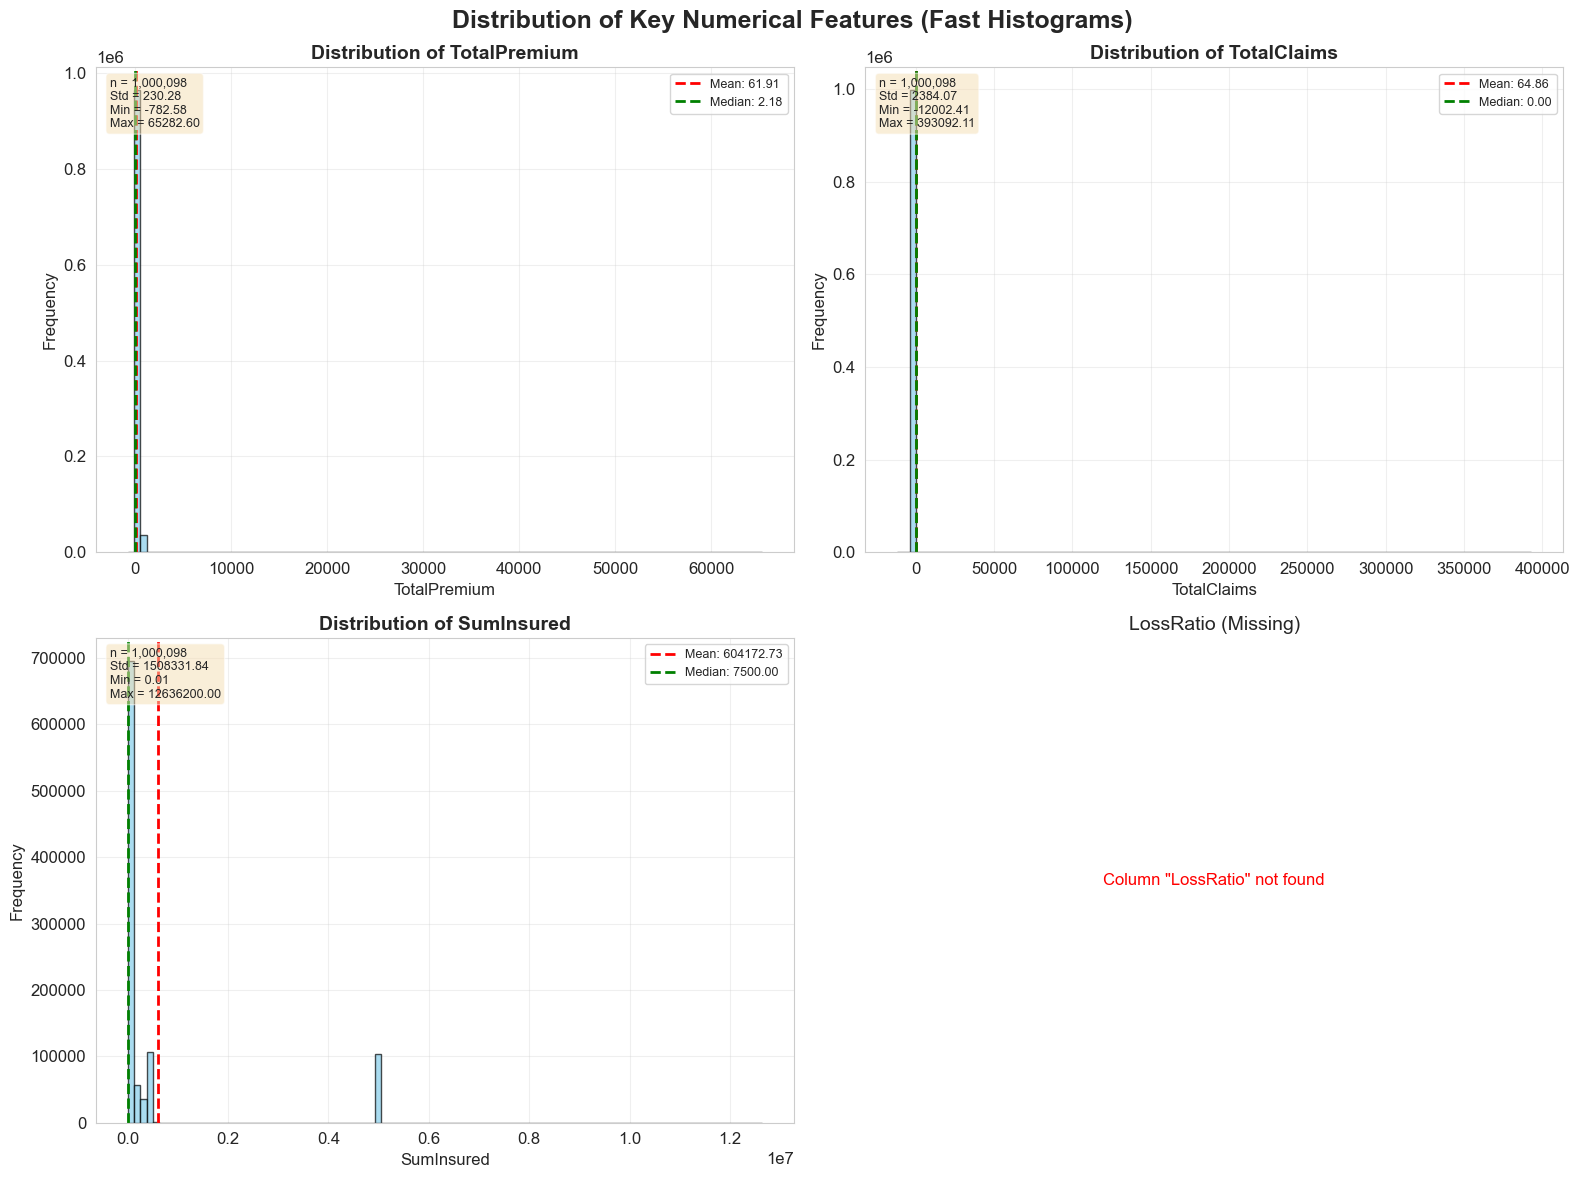

 Successfully created 3 distribution plots


In [7]:
# Cell 8: FAST Univariate Analysis - Distribution Plots
print("🎨 UNIVARIATE ANALYSIS - DISTRIBUTION PLOTS (Optimized for Speed)")
print("=" * 70)

visualizer = InsuranceVisualizer(style='seaborn')

# Create subplots for key numerical distributions
key_numerical = ['TotalPremium', 'TotalClaims', 'SumInsured', 'LossRatio']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Counter for successful plots
plots_created = 0

for idx, col in enumerate(key_numerical):
    if col in processor.df.columns:
        ax = axes[idx//2, idx%2]
        
        # Get clean data
        data = processor.df[col].dropna()
        
        if len(data) > 0:
            print(f"📊 Plotting {col}... ({len(data):,} data points)")
            
            # FAST METHOD: Use matplotlib hist directly (no KDE, no seaborn overhead)
            n, bins, patches = ax.hist(data, bins=100, color='skyblue', 
                                      edgecolor='black', alpha=0.7)
            
            ax.set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
            ax.set_xlabel(col, fontsize=12)
            ax.set_ylabel('Frequency', fontsize=12)
            ax.grid(True, alpha=0.3)
            
            # Add mean and median lines
            mean_val = data.mean()
            median_val = data.median()
            ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                      label=f'Mean: {mean_val:.2f}')
            ax.axvline(median_val, color='green', linestyle='--', linewidth=2, 
                      label=f'Median: {median_val:.2f}')
            
            # Add legend (place it outside if too crowded)
            ax.legend(loc='upper right', fontsize=9)
            
            # Add basic statistics as text
            stats_text = f'n = {len(data):,}\nStd = {data.std():.2f}\nMin = {data.min():.2f}\nMax = {data.max():.2f}'
            ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            
            plots_created += 1
            
        else:
            ax.text(0.5, 0.5, f'No data for {col}', 
                   ha='center', va='center', transform=ax.transAxes,
                   fontsize=12, color='red')
            ax.set_title(f'{col} (No Data)', fontsize=14)
            ax.axis('off')
    else:
        ax = axes[idx//2, idx%2]
        ax.text(0.5, 0.5, f'Column "{col}" not found', 
               ha='center', va='center', transform=ax.transAxes,
               fontsize=12, color='red')
        ax.set_title(f'{col} (Missing)', fontsize=14)
        ax.axis('off')

if plots_created > 0:
    plt.suptitle('Distribution of Key Numerical Features (Fast Histograms)', 
                 fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
    print(f" Successfully created {plots_created} distribution plots")
else:
    print(" No data available for any of the specified columns")

# Categorical distributions

📊 CATEGORICAL DISTRIBUTIONS


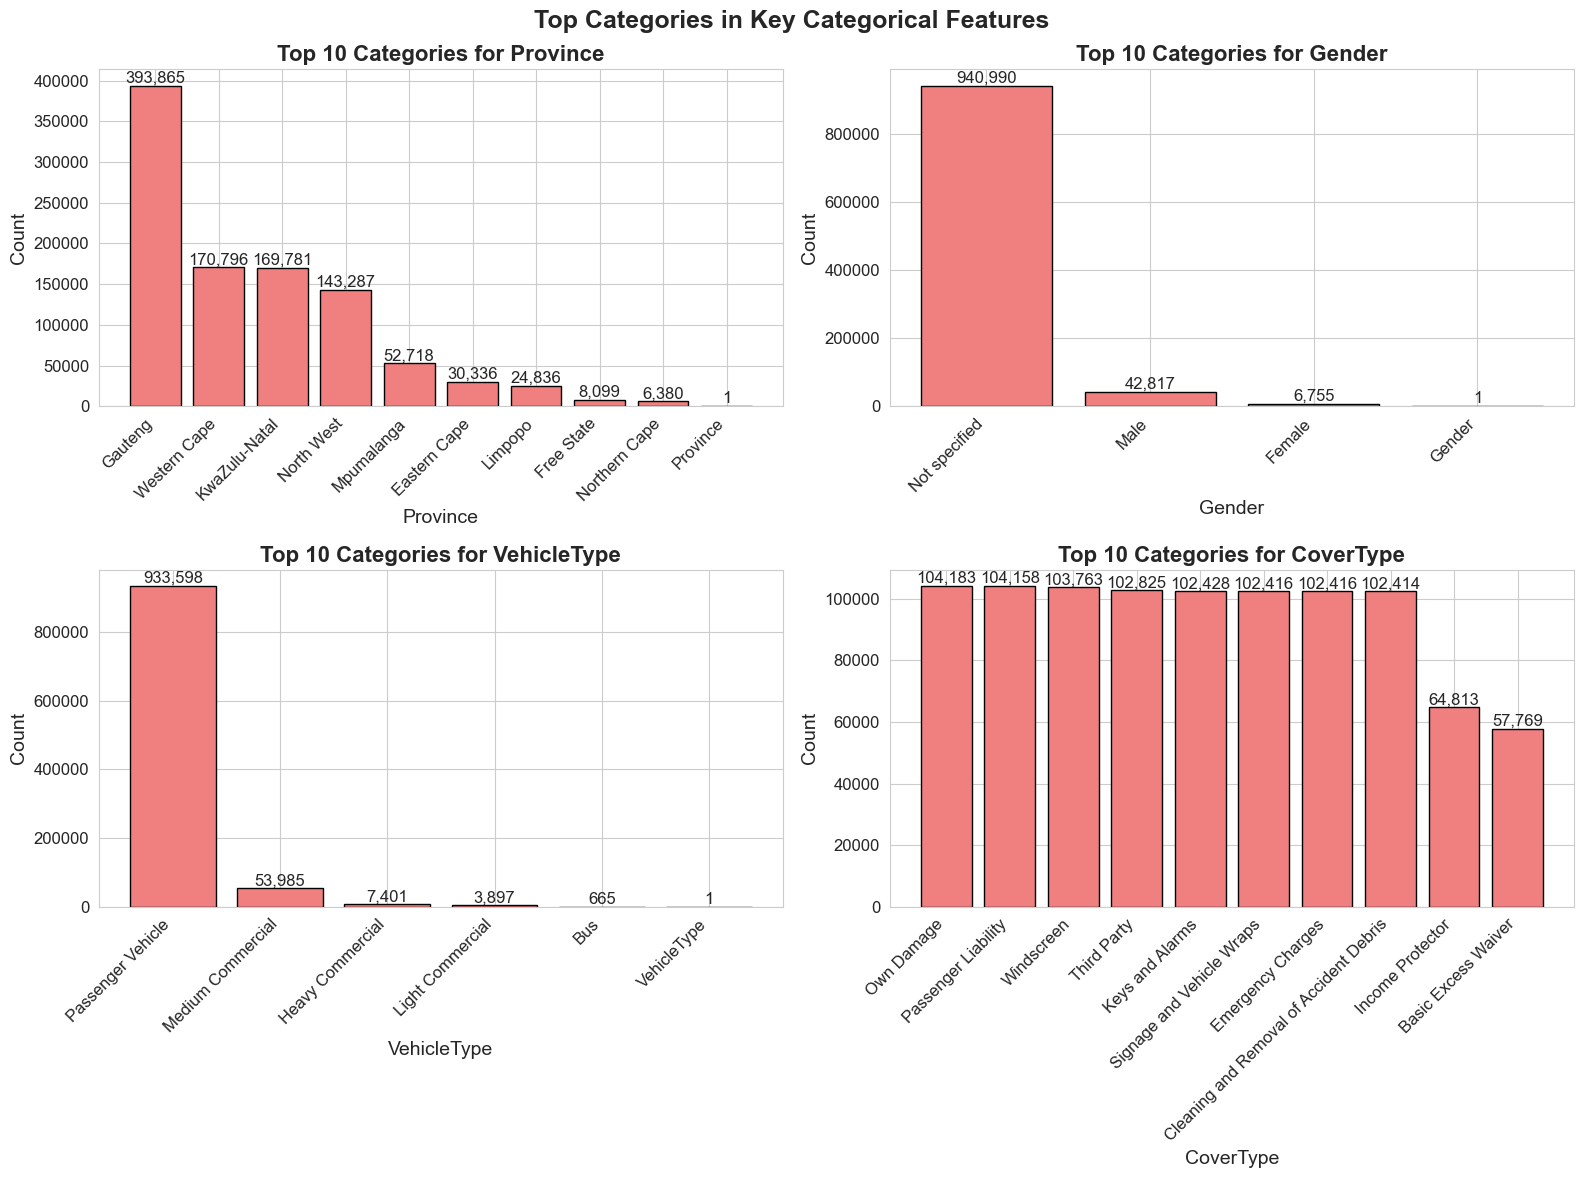

In [13]:
# Cell 9: Categorical distributions
print("📊 CATEGORICAL DISTRIBUTIONS")
print("=" * 60)

# Check for key categorical columns
key_categorical = ['Province', 'Gender', 'VehicleType', 'CoverType']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, col in enumerate(key_categorical):
    if col in processor.df.columns:
        ax = axes[idx//2, idx%2]
        visualizer.plot_categorical_distribution(processor.df[col].dropna(), col, top_n=10, ax=ax)

plt.suptitle('Top Categories in Key Categorical Features', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

#  Bivariate analysis - Correlation

🔗 BIVARIATE ANALYSIS - CORRELATION MATRIX
Calculating correlation matrix for 10 numerical columns...
Correlation matrix shape: (10, 10)


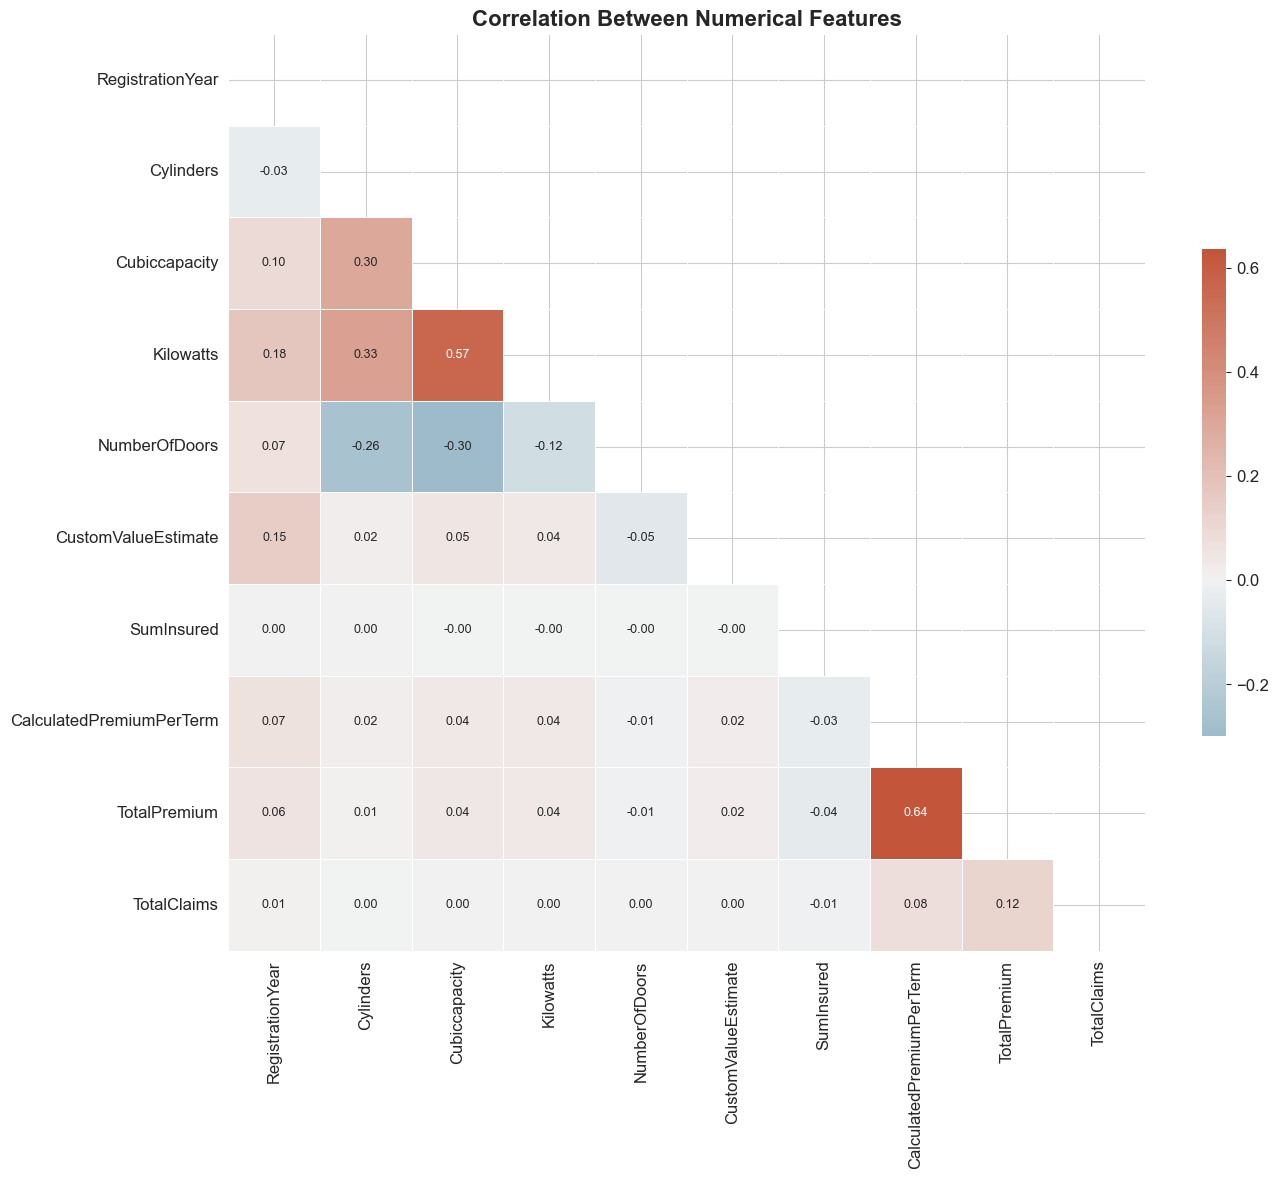


💪 STRONG CORRELATIONS (|r| > 0.7):
  No strong correlations found (|r| > 0.7)

📊 MODERATE CORRELATIONS (0.5 < |r| <= 0.7):
  Cubiccapacity ↔ Kilowatts: r = 0.567
  CalculatedPremiumPerTerm ↔ TotalPremium: r = 0.636


In [8]:
# Cell 10: Bivariate analysis - Correlation
print("🔗 BIVARIATE ANALYSIS - CORRELATION MATRIX")
print("=" * 60)

# First check if the method exists
if hasattr(processor, 'get_correlation_matrix'):
    corr_matrix = processor.get_correlation_matrix()
else:
    print("⚠️  get_correlation_matrix method not found, calculating manually...")
    # Manual calculation
    if len(processor.numerical_cols) > 1:
        corr_matrix = processor.df[processor.numerical_cols].corr()
    else:
        print("❌ Not enough numerical columns for correlation analysis")
        corr_matrix = pd.DataFrame()

if not corr_matrix.empty and corr_matrix.shape[0] > 0:
    print(f"Correlation matrix shape: {corr_matrix.shape}")
    
    # Create visualization
    if hasattr(visualizer, 'plot_correlation_heatmap'):
        fig = visualizer.plot_correlation_heatmap(corr_matrix, 'Correlation Between Numerical Features')
        plt.show()
    else:
        print("⚠️  plot_correlation_heatmap method not found in visualizer")
        # Create simple heatmap
        plt.figure(figsize=(12, 10))
        sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
        plt.title('Correlation Between Numerical Features')
        plt.tight_layout()
        plt.show()
    
    # Print strong correlations
    print("\n💪 STRONG CORRELATIONS (|r| > 0.7):")
    strong_corrs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.7:
                strong_corrs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_val))
    
    if strong_corrs:
        print(f"Found {len(strong_corrs)} strong correlations:")
        for corr in strong_corrs[:10]:  # Show top 10
            print(f"  {corr[0]} ↔ {corr[1]}: r = {corr[2]:.3f}")
    else:
        print("  No strong correlations found (|r| > 0.7)")
    
    # Print moderate correlations (0.5 < |r| <= 0.7)
    print("\n📊 MODERATE CORRELATIONS (0.5 < |r| <= 0.7):")
    moderate_corrs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if 0.5 < abs(corr_val) <= 0.7:
                moderate_corrs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_val))
    
    if moderate_corrs:
        for corr in moderate_corrs[:10]:  # Show top 10
            print(f"  {corr[0]} ↔ {corr[1]}: r = {corr[2]:.3f}")
    else:
        print("  No moderate correlations found")
        
else:
    print("❌ Correlation matrix is empty or could not be calculated")
    print(f"Numerical columns available: {len(processor.numerical_cols)}")
    if len(processor.numerical_cols) > 0:
        print(f"First 5 numerical columns: {processor.numerical_cols[:5]}")

# Outlier detection

🚨 OUTLIER DETECTION
Checking outliers for: ['TotalPremium', 'TotalClaims', 'SumInsured']


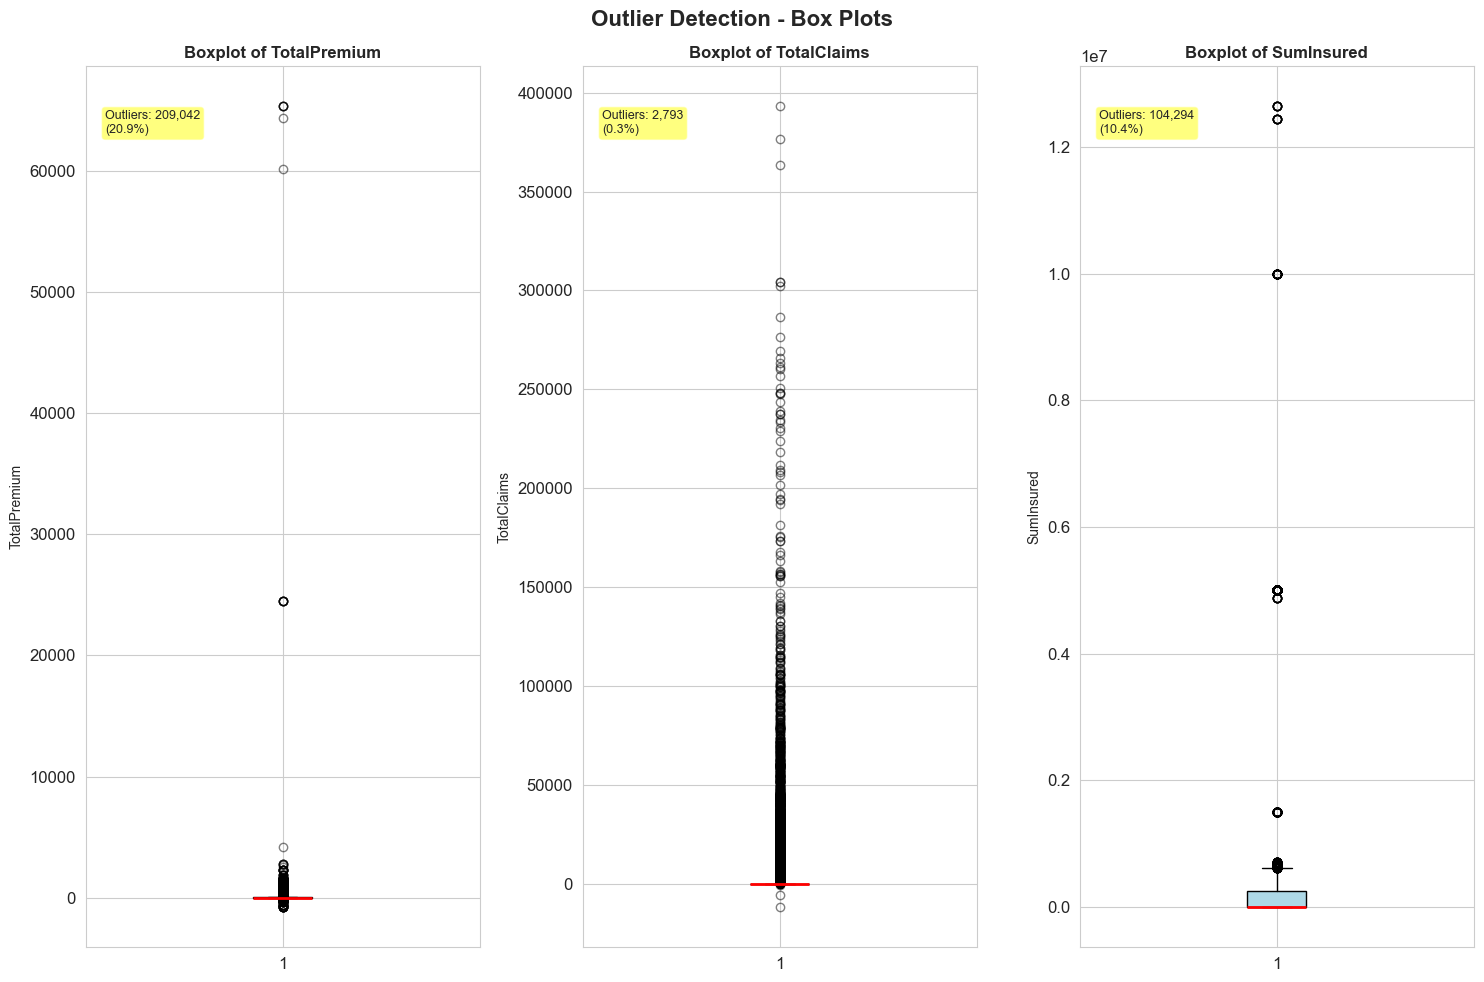


📊 OUTLIER STATISTICS (IQR Method):

TotalPremium:
  - Total values: 1,000,098
  - Outliers: 209,042 (20.9%)
  - Bounds: [-32.89, 54.82]
  - Min: -782.58, Max: 65282.60

TotalClaims:
  - Total values: 1,000,098
  - Outliers: 2,793 (0.3%)
  - Bounds: [0.00, 0.00]
  - Min: -12002.41, Max: 393092.11

SumInsured:
  - Total values: 1,000,098
  - Outliers: 104,294 (10.4%)
  - Bounds: [-362500.00, 617500.00]
  - Min: 0.01, Max: 12636200.00


In [9]:
# Cell 11: Outlier detection
print("🚨 OUTLIER DETECTION")
print("=" * 60)

# Check outliers in key numerical columns
outlier_cols = ['TotalPremium', 'TotalClaims', 'SumInsured', 'LossRatio']

# Check which columns exist
available_cols = [col for col in outlier_cols if col in processor.df.columns]
print(f"Checking outliers for: {available_cols}")

if available_cols:
    fig = visualizer.plot_boxplots_outliers(processor.df, available_cols)
    plt.show()
    
    print("\n📊 OUTLIER STATISTICS (IQR Method):")
    for col in available_cols:
        # You need to add detect_outliers_iqr method to your data_processor.py
        # For now, let's calculate manually
        data = processor.df[col].dropna()
        if len(data) > 0:
            Q1 = data.quantile(0.25)
            Q3 = data.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outliers = data[(data < lower_bound) | (data > upper_bound)]
            
            print(f"\n{col}:")
            print(f"  - Total values: {len(data):,}")
            print(f"  - Outliers: {len(outliers):,} ({len(outliers)/len(data)*100:.1f}%)")
            print(f"  - Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
            print(f"  - Min: {data.min():.2f}, Max: {data.max():.2f}")
else:
    print(f"❌ None of the specified columns found in data")
    print(f"Available numerical columns: {processor.numerical_cols}")

# CREATIVE VISUALIZATION 1 - Loss Ratio by Province

🎨 CREATIVE VISUALIZATION 1: Loss Ratio by Province


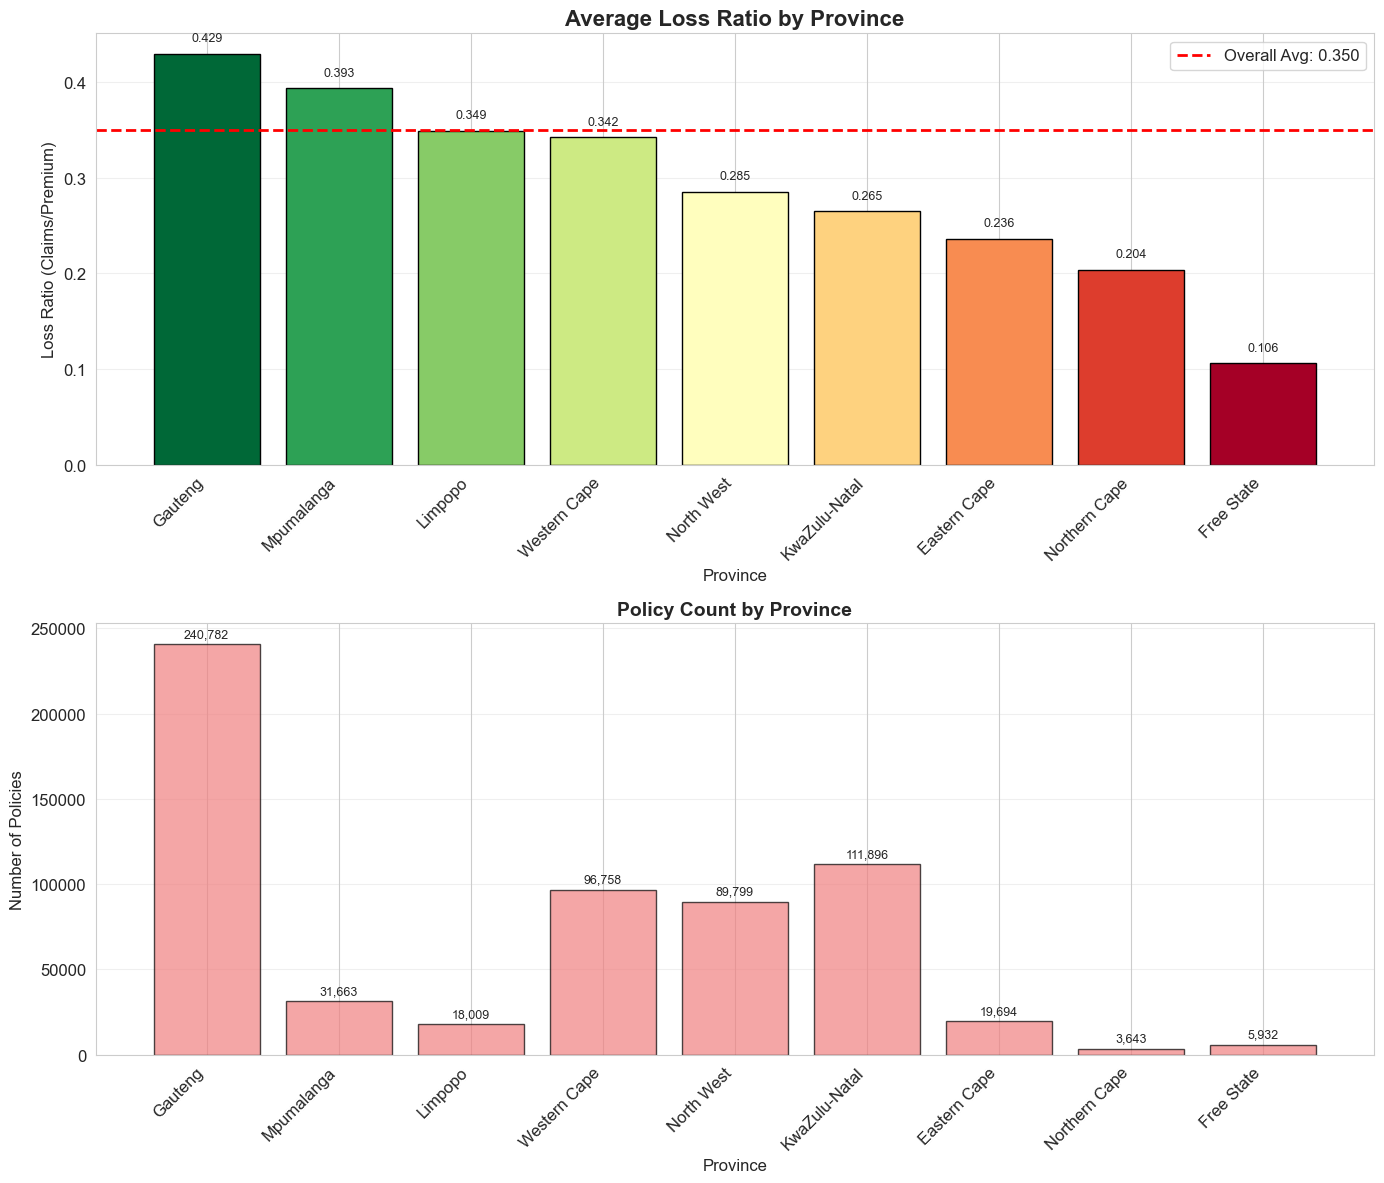


💡 KEY INSIGHTS:
  - Highest Loss Ratio: Gauteng (0.429)
  - Lowest Loss Ratio: Free State (0.106)
  - Most Policies: Gauteng (393,865 policies)


In [20]:
# Cell 12: CREATIVE VISUALIZATION 1 - Loss Ratio by Province
print("🎨 CREATIVE VISUALIZATION 1: Loss Ratio by Province")
print("=" * 60)

if 'Province' in processor.df.columns:
    fig = visualizer.plot_loss_ratio_by_category(processor.df, 'Province', 'Province')
    plt.show()
    
    # Calculate and display insights
    province_stats = processor.df.groupby('Province').agg({
        'LossRatio': 'mean',
        'TotalPremium': 'sum',
        'PolicyID': 'count'
    }).sort_values('LossRatio', ascending=False)
    
    print("\n💡 KEY INSIGHTS:")
    print(f"  - Highest Loss Ratio: {province_stats['LossRatio'].idxmax()} ({province_stats['LossRatio'].max():.3f})")
    print(f"  - Lowest Loss Ratio: {province_stats['LossRatio'].idxmin()} ({province_stats['LossRatio'].min():.3f})")
    print(f"  - Most Policies: {province_stats['PolicyID'].idxmax()} ({province_stats['PolicyID'].max():,} policies)")

# CREATIVE VISUALIZATION 2 - Interactive Temporal Trends

🎨 CREATIVE VISUALIZATION 2: Fast Temporal Analysis
Using date column: TransactionMonth

📊 Processing temporal data...

📅 DATE RANGE:
  - Min: 2013-10-01 00:00:00
  - Max: 2015-08-01 00:00:00
  - Using 100,000 samples for fast visualization


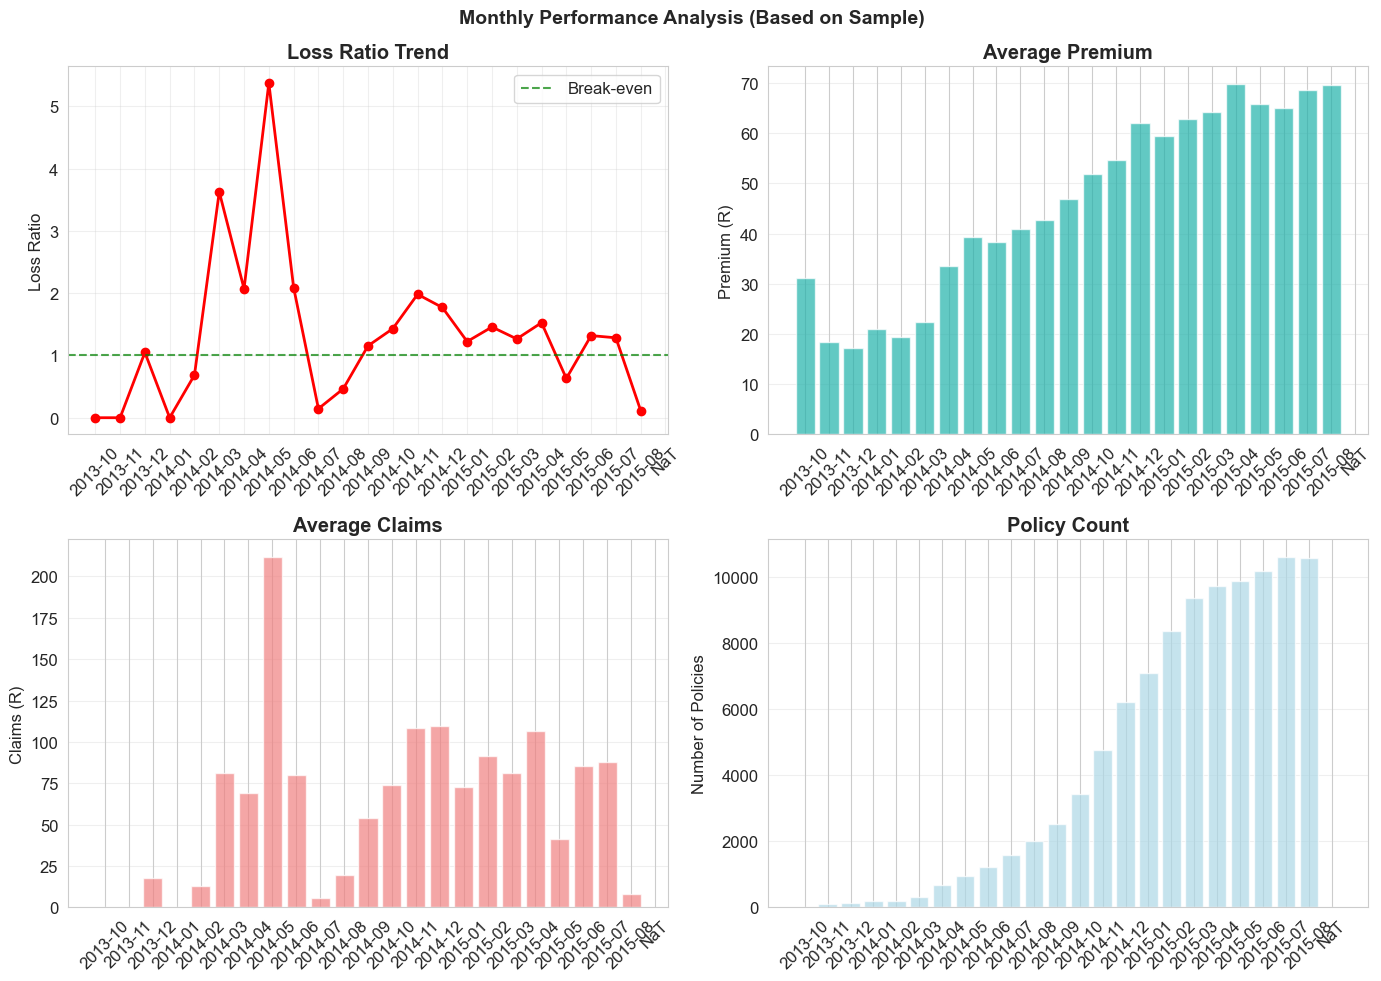


📈 KEY TEMPORAL INSIGHTS:
  • Worst month: 2014-05 (Loss Ratio: 5.374)
  • Best month: 2013-10 (Loss Ratio: 0.000)
  • Average Loss Ratio: 1.333
  • Months analyzed: 24


In [6]:
# Cell 13: FAST Temporal Analysis
print("🎨 CREATIVE VISUALIZATION 2: Fast Temporal Analysis")
print("=" * 60)

# Find date column
if 'TransactionMonth' in processor.df.columns:
    date_col = 'TransactionMonth'
    print(f"Using date column: {date_col}")
    
    # FAST METHOD: Use pre-aggregated data
    print("\n📊 Processing temporal data...")
    
    # First, ensure it's datetime
    if not pd.api.types.is_datetime64_any_dtype(processor.df[date_col]):
        processor.df[date_col] = pd.to_datetime(processor.df[date_col], errors='coerce')
    
    # Get date range info FIRST (fast)
    print(f"\n📅 DATE RANGE:")
    print(f"  - Min: {processor.df[date_col].min()}")
    print(f"  - Max: {processor.df[date_col].max()}")
    
    # SAMPLE for speed - take 10% of data
    sample_size = min(100000, len(processor.df))
    df_sample = processor.df.sample(n=sample_size, random_state=42)
    print(f"  - Using {sample_size:,} samples for fast visualization")
    
    # Create monthly aggregates from sample
    df_sample['YearMonth'] = df_sample[date_col].dt.to_period('M').astype(str)
    monthly_data = df_sample.groupby('YearMonth').agg({
        'TotalPremium': 'mean',  # Use mean instead of sum for sample
        'TotalClaims': 'mean',
        'PolicyID': 'count'
    }).reset_index()
    
    monthly_data['LossRatio'] = monthly_data['TotalClaims'] / monthly_data['TotalPremium']
    
    # Create FAST visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Loss Ratio Trend
    axes[0, 0].plot(monthly_data['YearMonth'], monthly_data['LossRatio'], 'r-o', linewidth=2)
    axes[0, 0].axhline(y=1, color='green', linestyle='--', alpha=0.7, label='Break-even')
    axes[0, 0].set_title('Loss Ratio Trend', fontweight='bold')
    axes[0, 0].set_ylabel('Loss Ratio')
    axes[0, 0].legend()
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Premium Trend
    axes[0, 1].bar(monthly_data['YearMonth'], monthly_data['TotalPremium'], 
                   color='lightseagreen', alpha=0.7)
    axes[0, 1].set_title('Average Premium', fontweight='bold')
    axes[0, 1].set_ylabel('Premium (R)')
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # 3. Claims Trend
    axes[1, 0].bar(monthly_data['YearMonth'], monthly_data['TotalClaims'], 
                   color='lightcoral', alpha=0.7)
    axes[1, 0].set_title('Average Claims', fontweight='bold')
    axes[1, 0].set_ylabel('Claims (R)')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # 4. Policy Count
    axes[1, 1].bar(monthly_data['YearMonth'], monthly_data['PolicyID'], 
                   color='lightblue', alpha=0.7)
    axes[1, 1].set_title('Policy Count', fontweight='bold')
    axes[1, 1].set_ylabel('Number of Policies')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.suptitle('Monthly Performance Analysis (Based on Sample)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print key insights
    print(f"\n📈 KEY TEMPORAL INSIGHTS:")
    worst_month = monthly_data.loc[monthly_data['LossRatio'].idxmax()]
    best_month = monthly_data.loc[monthly_data['LossRatio'].idxmin()]
    
    print(f"  • Worst month: {worst_month['YearMonth']} (Loss Ratio: {worst_month['LossRatio']:.3f})")
    print(f"  • Best month: {best_month['YearMonth']} (Loss Ratio: {best_month['LossRatio']:.3f})")
    print(f"  • Average Loss Ratio: {monthly_data['LossRatio'].mean():.3f}")
    print(f"  • Months analyzed: {len(monthly_data)}")
    
elif 'TransactionMonth' not in processor.df.columns:
    print("❌ TransactionMonth column not found")
    
    # Check for other date columns
    date_like = [col for col in processor.df.columns if any(x in col.lower() 
                for x in ['date', 'month', 'time'])]
    if date_like:
        print(f"📅 Found potential date columns: {date_like}")
    else:
        print("📅 No date columns found in data")

# CREATIVE VISUALIZATION 3 - Vehicle Make Analysis

🎨 CREATIVE VISUALIZATION 3: Vehicle Make Risk Analysis


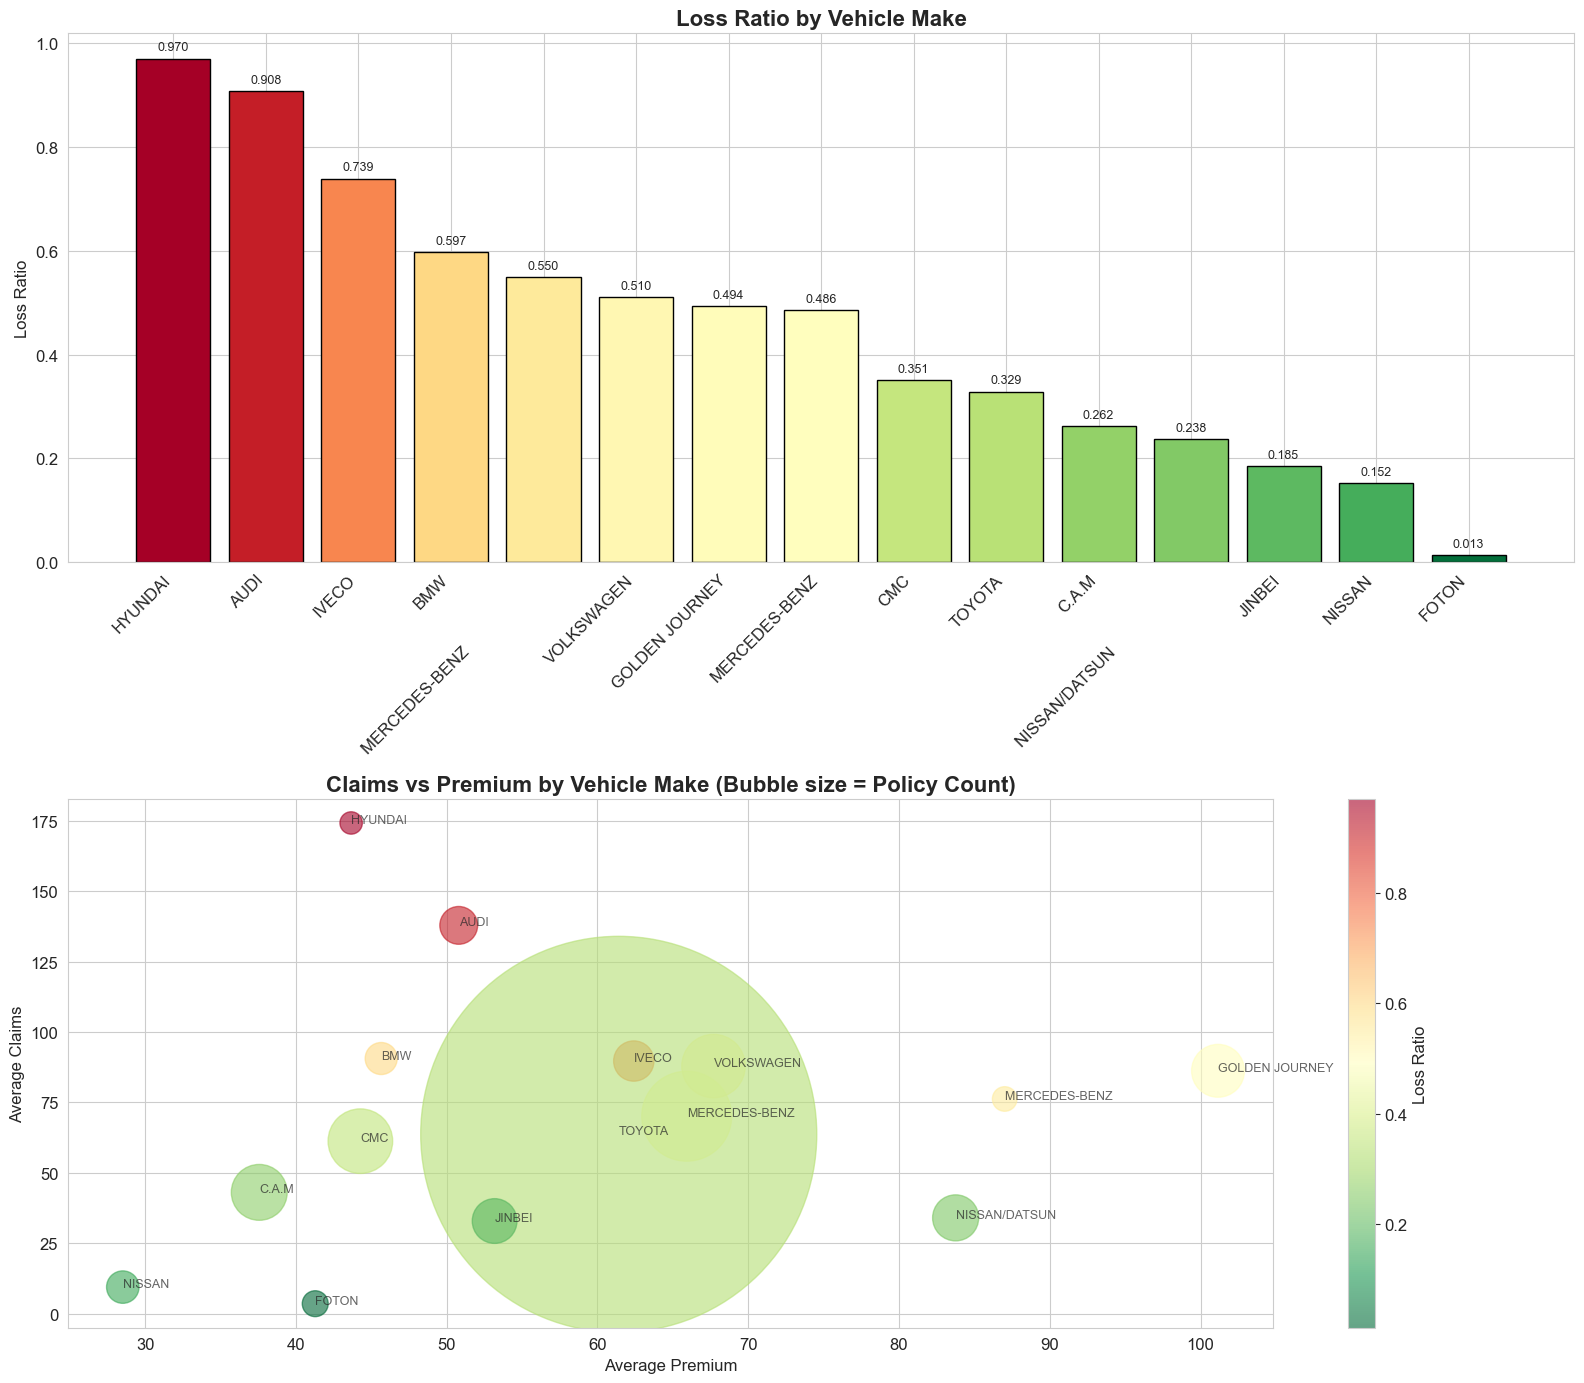


🚗 RISKIEST VEHICLE MAKES (Highest Loss Ratio):
  - HYUNDAI: Loss Ratio = 0.970
  - AUDI: Loss Ratio = 0.908
  - IVECO: Loss Ratio = 0.739

💰 MOST PROFITABLE VEHICLE MAKES (Lowest Loss Ratio):
  - JINBEI: Loss Ratio = 0.185
  - NISSAN: Loss Ratio = 0.152
  - FOTON: Loss Ratio = 0.013


In [19]:
# Cell 14: CREATIVE VISUALIZATION 3 - Vehicle Make Analysis
print("🎨 CREATIVE VISUALIZATION 3: Vehicle Make Risk Analysis")
print("=" * 60)

if 'Make' in processor.df.columns:
    # Get top 15 vehicle makes
    top_makes = processor.df['Make'].value_counts().head(15).index
    
    # Filter data
    make_data = processor.df[processor.df['Make'].isin(top_makes)]
    
    # Calculate metrics by make
    make_stats = make_data.groupby('Make').agg({
        'LossRatio': 'mean',
        'TotalClaims': 'mean',
        'TotalPremium': 'mean',
        'PolicyID': 'count'
    }).sort_values('LossRatio', ascending=False)
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 14))
    
    # Bar plot for loss ratio
    bars1 = ax1.bar(range(len(make_stats)), make_stats['LossRatio'], 
                   color=plt.cm.RdYlGn_r(make_stats['LossRatio'] / make_stats['LossRatio'].max()),
                   edgecolor='black')
    ax1.set_title('Loss Ratio by Vehicle Make', fontsize=16, fontweight='bold')
    ax1.set_ylabel('Loss Ratio')
    ax1.set_xticks(range(len(make_stats)))
    ax1.set_xticklabels(make_stats.index, rotation=45, ha='right')
    
    # Add value labels
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    # Scatter plot for claims vs premium
    scatter = ax2.scatter(make_stats['TotalPremium'], make_stats['TotalClaims'],
                         s=make_stats['PolicyID']/10, alpha=0.6,
                         c=make_stats['LossRatio'], cmap='RdYlGn_r')
    
    ax2.set_title('Claims vs Premium by Vehicle Make (Bubble size = Policy Count)', 
                 fontsize=16, fontweight='bold')
    ax2.set_xlabel('Average Premium')
    ax2.set_ylabel('Average Claims')
    
    # Add make labels to scatter plot
    for make, row in make_stats.iterrows():
        ax2.annotate(make, (row['TotalPremium'], row['TotalClaims']),
                    fontsize=9, alpha=0.7)
    
    # Add colorbar
    plt.colorbar(scatter, ax=ax2, label='Loss Ratio')
    
    plt.tight_layout()
    plt.show()
    
    print("\n🚗 RISKIEST VEHICLE MAKES (Highest Loss Ratio):")
    for make, lr in make_stats['LossRatio'].head(3).items():
        print(f"  - {make}: Loss Ratio = {lr:.3f}")
    
    print("\n💰 MOST PROFITABLE VEHICLE MAKES (Lowest Loss Ratio):")
    for make, lr in make_stats['LossRatio'].tail(3).items():
        print(f"  - {make}: Loss Ratio = {lr:.3f}")

# 1. Profitability Distribution:

Text(0, 0.5, 'Number of Policies')

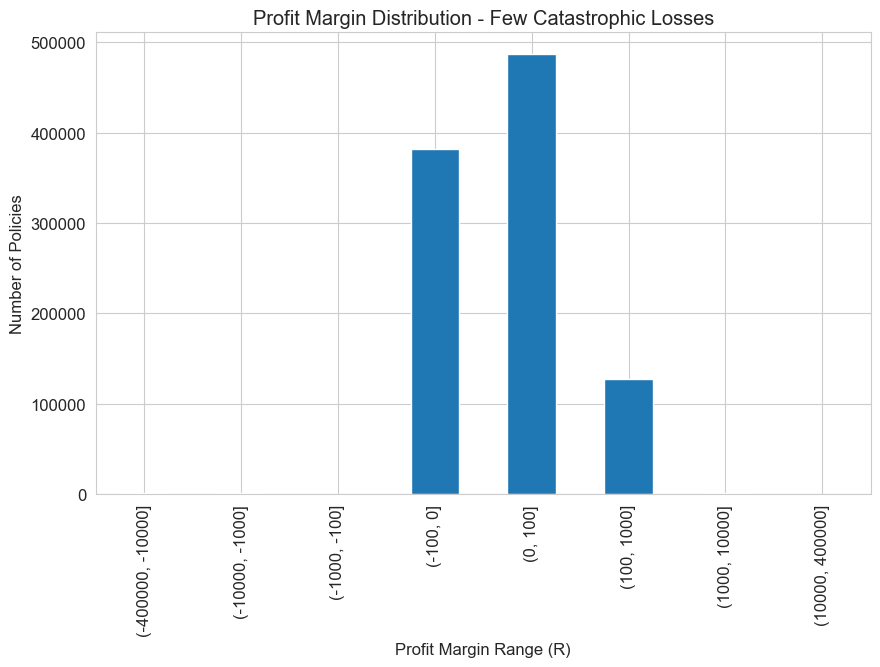

In [18]:
# Show how few loss-makers destroy profitability
plt.figure(figsize=(10,6))
profit_bins = pd.cut(processor.df['ProfitMargin'], 
                     bins=[-400000, -10000, -1000, -100, 0, 100, 1000, 10000, 400000])
profit_bins.value_counts().sort_index().plot(kind='bar')
plt.title('Profit Margin Distribution - Few Catastrophic Losses')
plt.xlabel('Profit Margin Range (R)')
plt.ylabel('Number of Policies')

# 2. Premium vs Claim Analysis:

Text(0, 0.5, 'Claim Amount (R, log scale)')

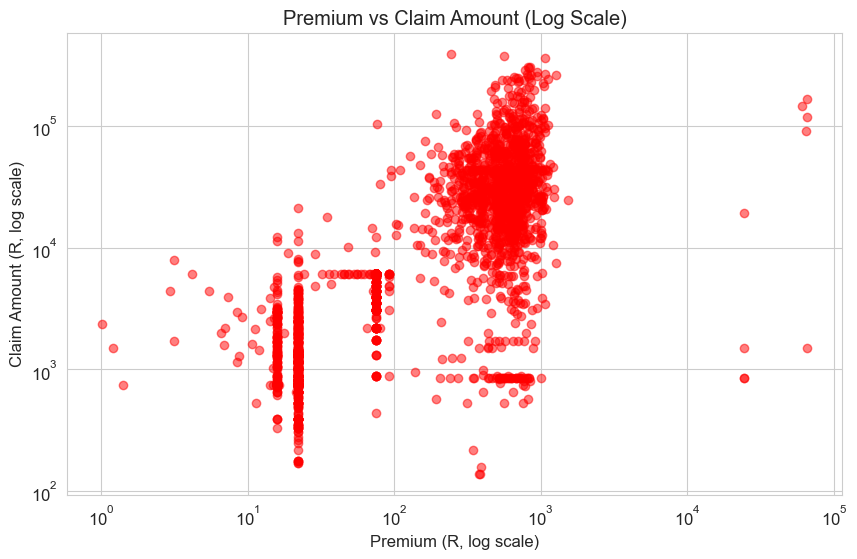

In [17]:
# Scatter plot: Premium vs Claim size (log scale)
claim_data = processor.df[processor.df['HasClaim'] == 1]
plt.figure(figsize=(10,6))
plt.scatter(claim_data['TotalPremium'], claim_data['TotalClaims'], 
            alpha=0.5, c='red')
plt.xscale('log')
plt.yscale('log')
plt.title('Premium vs Claim Amount (Log Scale)')
plt.xlabel('Premium (R, log scale)')
plt.ylabel('Claim Amount (R, log scale)')

# 3. Missing Data Heatmap:

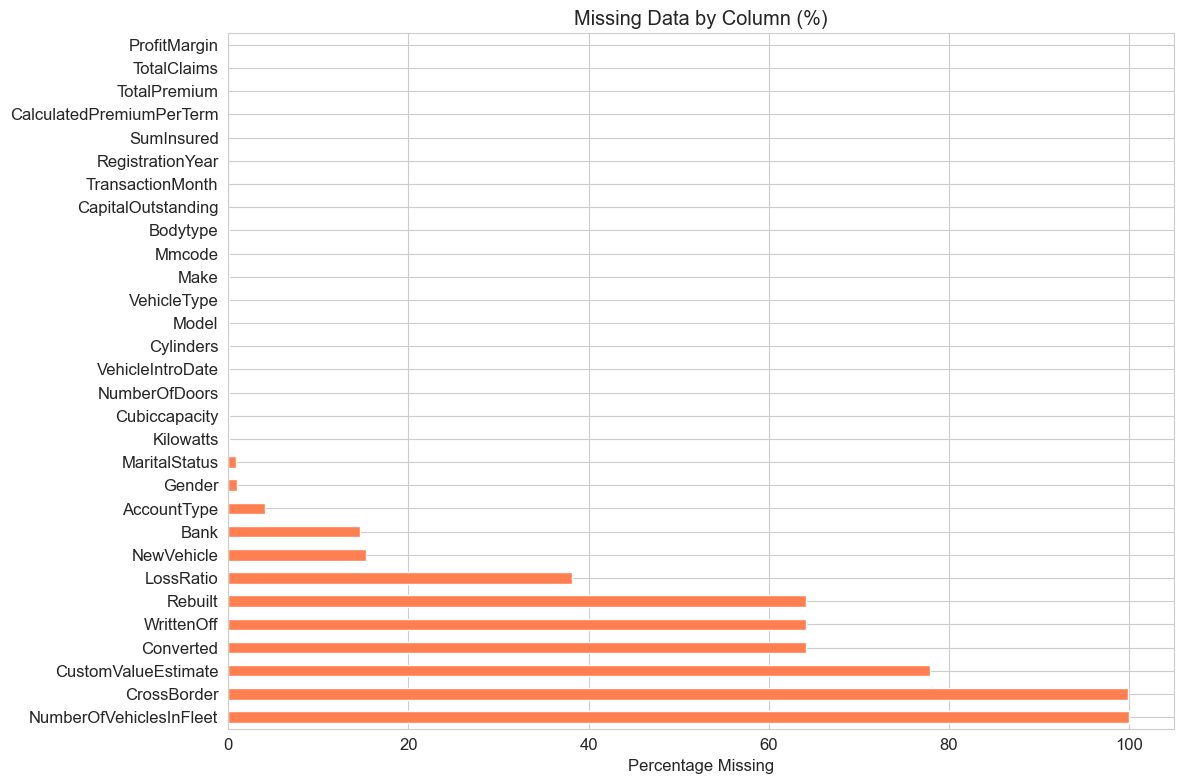

In [16]:
# Show which columns have missing data
missing_pct = (processor.df.isnull().sum() / len(processor.df)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

plt.figure(figsize=(12,8))
missing_pct.plot(kind='barh', color='coral')
plt.title('Missing Data by Column (%)')
plt.xlabel('Percentage Missing')
plt.tight_layout()

# Summary and Insights

In [15]:
# Cell 15: Summary and Insights
print("📊 EDA SUMMARY & KEY INSIGHTS")
print("=" * 60)

print("\n🔑 KEY FINDINGS:")
print("1. DATA OVERVIEW")
print(f"   - Total policies analyzed: {len(processor.df):,}")
print(f"   - Overall Loss Ratio: {processor.df['LossRatio'].mean():.3f}")
print(f"   - Claim Rate: {(processor.df['HasClaim'].mean() * 100):.1f}% of policies have claims")

print("\n2. RISK PATTERNS")
if 'Province' in processor.df.columns:
    province_risk = processor.df.groupby('Province')['LossRatio'].mean().sort_values(ascending=False)
    print(f"   - Highest risk province: {province_risk.index[0]} (LR: {province_risk.iloc[0]:.3f})")
    print(f"   - Lowest risk province: {province_risk.index[-1]} (LR: {province_risk.iloc[-1]:.3f})")

if 'Gender' in processor.df.columns:
    gender_risk = processor.df.groupby('Gender')['LossRatio'].mean()
    print(f"   - Gender risk difference: {abs(gender_risk.diff().iloc[-1]):.3f}")

print("\n3. BUSINESS IMPLICATIONS")
print("   - Consider premium adjustments for high-risk provinces")
print("   - Investigate vehicle makes with consistently high loss ratios")
print("   - Monitor temporal trends for seasonality effects")
print("   - Address data quality issues before modeling")

print("\n4. NEXT STEPS")
print("   - Proceed to hypothesis testing (Task 3)")
print("   - Prepare data for predictive modeling")
print("   - Set up DVC for data versioning")

📊 EDA SUMMARY & KEY INSIGHTS

🔑 KEY FINDINGS:
1. DATA OVERVIEW
   - Total policies analyzed: 1,000,099
   - Overall Loss Ratio: 0.350
   - Claim Rate: 0.3% of policies have claims

2. RISK PATTERNS
   - Highest risk province: Gauteng (LR: 0.429)
   - Lowest risk province: Province (LR: nan)
   - Gender risk difference: 0.005

3. BUSINESS IMPLICATIONS
   - Consider premium adjustments for high-risk provinces
   - Investigate vehicle makes with consistently high loss ratios
   - Monitor temporal trends for seasonality effects
   - Address data quality issues before modeling

4. NEXT STEPS
   - Proceed to hypothesis testing (Task 3)
   - Prepare data for predictive modeling
   - Set up DVC for data versioning
